# Rebuild `uni.mglyph`

Generates `data/uni.mglyph`: gray triangles, splits `"0"` (train) and `"1"` (test), 5000 samples each.


In [ ]:
import random
from pathlib import Path
from zipfile import ZipFile

import mglyph as mg
import numpy as np

from mglyph_ml.dataset.export import Drawer, create_dataset, export_dataset

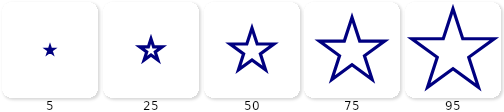

Generated: data/simple-star.mglyph-100000


In [ ]:
def triangle(x: float, canvas: mg.Canvas):
    canvas.tr.scale(mg.lerp(x, 0.05, 0.95))
    canvas.polygon([canvas.bottom_left, canvas.bottom_right, canvas.top_center], color="gray")


def star(x: float, canvas: mg.Canvas, bordercolor, fillcolor, linewidth) -> None:
    canvas.tr.translate(0, mg.lerp(x, 0, 0.05))
    radius = mg.lerp(x, 0.01, canvas.ysize / 2)

    vertices = []
    for segment in range(5):
        vertices.append(mg.orbit(canvas.center, segment * 2 * np.pi / 5, radius))
        vertices.append(
            mg.orbit(
                canvas.center,
                (segment + 0.5) * 2 * np.pi / 5,
                np.cos(2 * np.pi / 5) / np.cos(np.pi / 5) * radius,
            )
        )

    canvas.polygon(vertices, linecap="round", style="fill", color=fillcolor)
    canvas.polygon(vertices, width=linewidth, linecap="round", style="stroke", color=bordercolor)


def simple_star() -> Drawer:
    bordercolor = "navy"
    fillcolor = "white"
    linewidth = "70p"
    return lambda x, canvas: star(x, canvas, bordercolor, fillcolor, linewidth)

mg.show(simple_star()) # type: ignore

export_dataset("Simple Star", Path("data/simple-star-10000.mglyph"), simple_star(), sample_n=100)